# 01 - Structural break detection (Phase 2)

**Why the first version flagged 100% of items:** mean/std were computed over the whole series, the CUSUM started on day 1 with no burn-in, and it ran on daily data (day-of-week seasonality + autocorrelation) with the textbook iid threshold (h=5σ). Any trend or ramp-up guaranteed an early alarm.

**Fixed method (src/break_detection.py):**
1. Aggregate to full Sat-Fri weeks (removes day-of-week seasonality).
2. Burn-in: ignore the first 8 weeks after launch (ramp-up).
3. Reference window: next 52 weeks -> baseline mean/std (a full year, so normal seasonal swings are in the baseline).
4. Monitor only after the reference window; two-sided tabular CUSUM with k=1.0σ (tuned for shifts of roughly 2σ).
5. Threshold h is **calibrated**, not assumed: each item's reference window is block-bootstrapped (4-week blocks) into break-free surrogates, and h = 95th percentile of the surrogate max statistic -> ~5% false alarms per series on break-free data. Checked on a second, independent set of surrogates.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from break_detection import (to_weekly, cusum_detect, surrogate_max_stats, run_cusum_on_candidates,
                             validate_against_christmas, pelt_detect, surrogate_series,
                             calibrate_pelt_penalty, power_check, step_vs_trend_bic,
                             weekly_ca_prices, sustained_price_changes, alignment_vs_chance)

BURN_IN, REF_LEN, K = 8, 52, 1.0
SEED_CALIB, SEED_CHECK = 42, 7

In [2]:
categories = ['foods', 'hobbies', 'household']
category_data = {}
weekly = {}

for cat in categories:
    long_df = pd.read_csv(f"../data/interim/{cat}_candidates.csv", parse_dates=['date'])
    category_data[cat] = long_df
    for item_id, grp in long_df.groupby('item_id'):
        weekly[(cat, item_id)] = to_weekly(grp.sort_values('date')).to_numpy()
    print(f"{cat}: {long_df['item_id'].nunique()} items, {len(long_df)} rows")

foods: 337 items, 609203 rows


hobbies: 106 items, 193523 rows


household: 283 items, 487284 rows


## Calibrate the threshold h on break-free surrogates

In [3]:
null_calib = surrogate_max_stats(weekly, burn_in=BURN_IN, ref_len=REF_LEN, k=K, seed=SEED_CALIB)
H = float(np.quantile(null_calib, 0.95))

null_check = surrogate_max_stats(weekly, burn_in=BURN_IN, ref_len=REF_LEN, k=K, seed=SEED_CHECK)
fp_check = (null_check > H).mean()

print(f"Calibrated h = {H:.2f} (textbook iid value would be ~5)")
print(f"False-alarm rate on independent surrogates: {fp_check:.1%} ({len(null_check)} surrogate series)")

Calibrated h = 14.38 (textbook iid value would be ~5)
False-alarm rate on independent surrogates: 4.8% (14520 surrogate series)


## Run the fixed CUSUM

In [4]:
all_break_results = {}
for cat, long_df in category_data.items():
    break_df = run_cusum_on_candidates(long_df, long_df['item_id'].unique().tolist(),
                                       burn_in=BURN_IN, ref_len=REF_LEN, k=K, h=H)
    break_df.insert(1, 'category', cat.upper())
    all_break_results[cat] = break_df

def summarise(df):
    b = df[df['break_detected']]
    return pd.Series({
        'items': len(df),
        'breaks': len(b),
        'pct_with_break': round(100 * len(b) / len(df), 1),
        'pct_downward': round(100 * (b['direction'] < 0).mean(), 1),
        'median_delay_wks': b['detection_delay_weeks'].median(),
        'median_abs_shift_sd': round(b['shift_in_sd'].abs().median(), 2),
    })

break_summary = pd.DataFrame({cat: summarise(df) for cat, df in all_break_results.items()}).T
pd.concat(all_break_results.values()).to_csv("../data/processed/cusum_breaks.csv", index=False)
print(break_summary)

           items  breaks  pct_with_break  pct_downward  median_delay_wks  \
foods      337.0   234.0            69.4          64.1              16.0   
hobbies    106.0    68.0            64.2          75.0              16.0   
household  283.0   186.0            65.7          61.3              16.5   

           median_abs_shift_sd  
foods                     1.92  
hobbies                   1.91  
household                 1.89  


### Where do breaks fall?
A cluster right at the start of monitoring (week 60 after launch) would point to a reference-window artefact (e.g. a launch ramp-up longer than the 8-week burn-in) rather than a real shift.

Change-point year counts:
change_week
2012    169
2013    168
2014     98
2015     49
2016      4

Share of breaks within 4 weeks of monitoring start: 17.4%


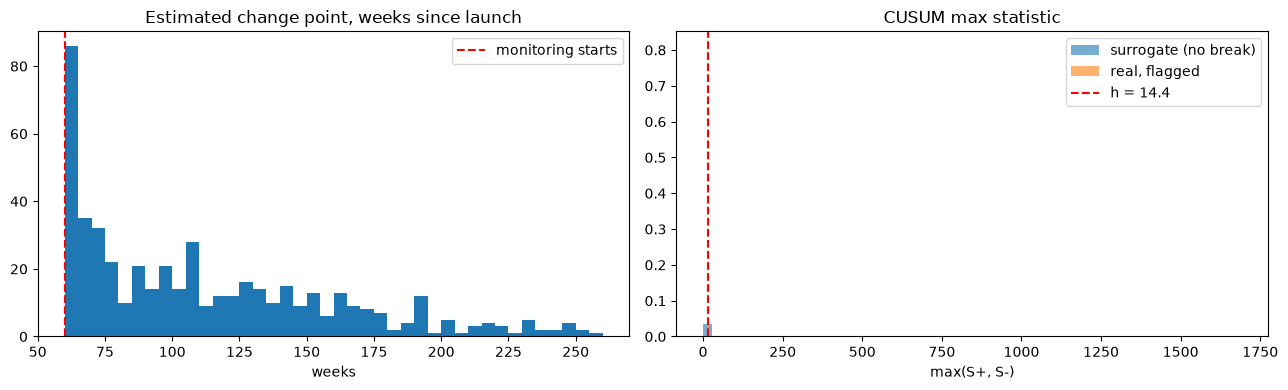

In [5]:
all_breaks = pd.concat(all_break_results.values())
flagged = all_breaks[all_breaks['break_detected']].copy()
first_sale = pd.concat(category_data.values()).groupby('item_id')['date'].min()
flagged['weeks_since_launch'] = (flagged['change_week'] - flagged['item_id'].map(first_sale)).dt.days / 7
monitor_start = BURN_IN + REF_LEN

print("Change-point year counts:")
print(flagged['change_week'].dt.year.value_counts().sort_index().to_string())
at_start = (flagged['weeks_since_launch'] <= monitor_start + 4).mean()
print(f"\nShare of breaks within 4 weeks of monitoring start: {at_start:.1%}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(flagged['weeks_since_launch'], bins=40)
ax[0].axvline(monitor_start, color='red', ls='--', label='monitoring starts')
ax[0].set(title='Estimated change point, weeks since launch', xlabel='weeks'); ax[0].legend()
ax[1].hist(null_check, bins=60, alpha=0.6, label='surrogate (no break)', density=True)
ax[1].hist(flagged['max_stat'].clip(upper=null_check.max()), bins=60, alpha=0.6, label='real, flagged', density=True)
ax[1].axvline(H, color='red', ls='--', label=f'h = {H:.1f}')
ax[1].set(title='CUSUM max statistic', xlabel='max(S+, S-)'); ax[1].legend()
plt.tight_layout()
plt.savefig("../outputs/figures/cusum_break_timing_and_null.png", dpi=120)
plt.show()

In [6]:
for cat, long_df in category_data.items():
    christmas_check = validate_against_christmas(all_break_results[cat], long_df)
    print(f"{cat}: Christmas Day was zero-sales in {christmas_check['is_zero'].mean()*100:.1f}% of item-years checked")

foods: Christmas Day was zero-sales in 98.7% of item-years checked


hobbies: Christmas Day was zero-sales in 100.0% of item-years checked


household: Christmas Day was zero-sales in 100.0% of item-years checked


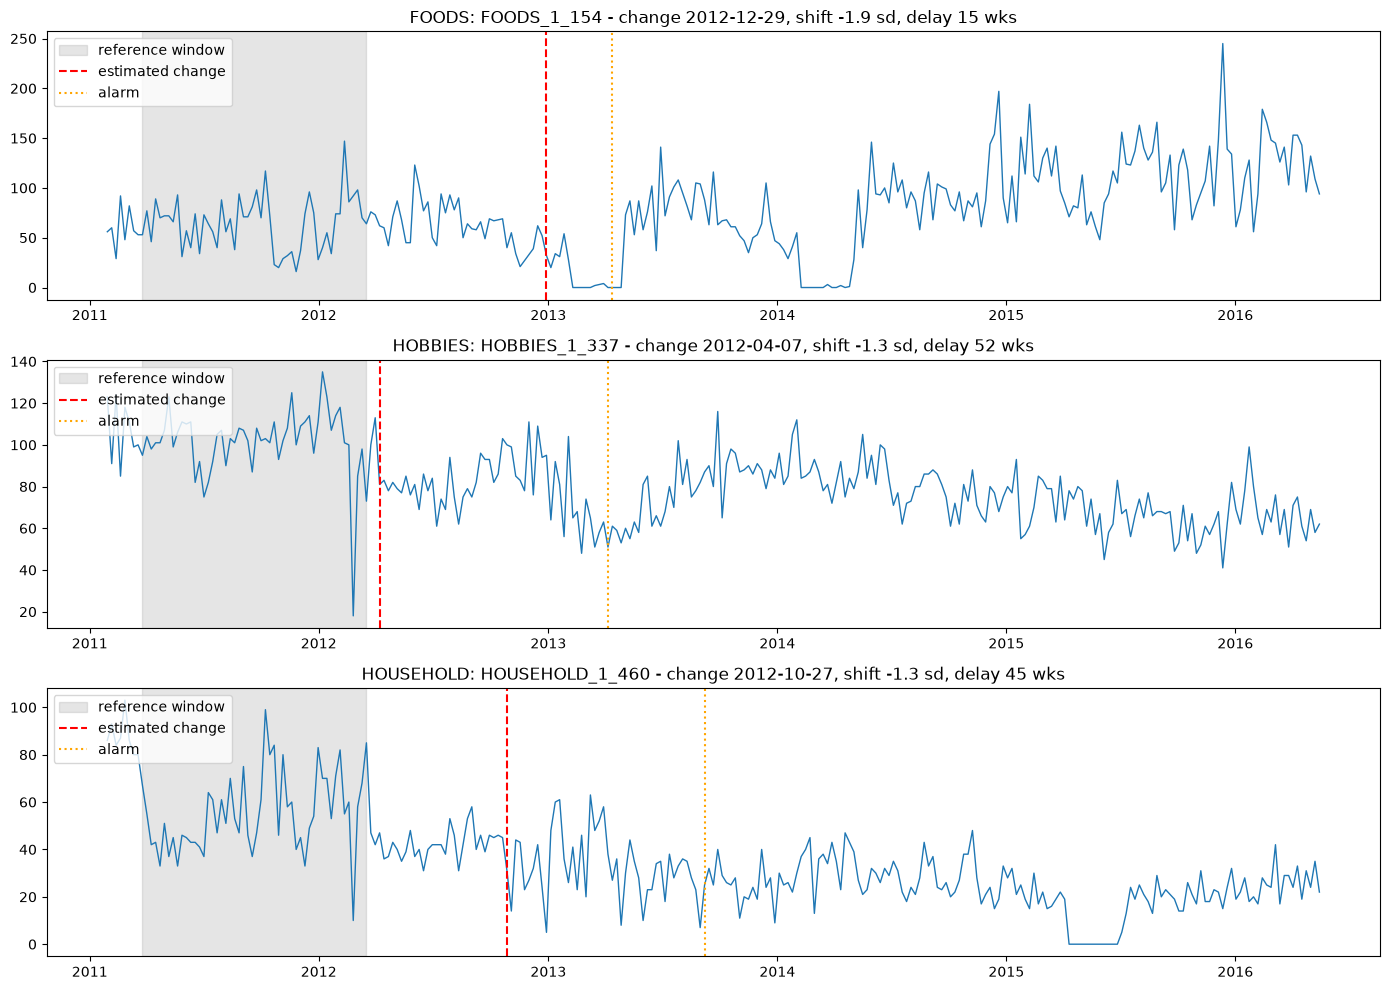

In [7]:
rng = np.random.default_rng(SEED_CALIB)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, (cat, long_df) in zip(axes, category_data.items()):
    flagged_cat = all_break_results[cat].query('break_detected')
    row = flagged_cat.iloc[rng.integers(len(flagged_cat))]
    w = to_weekly(long_df[long_df['item_id'] == row['item_id']].sort_values('date'))
    ax.plot(w.index, w.values, lw=1)
    ax.axvspan(w.index[BURN_IN], w.index[BURN_IN + REF_LEN - 1], color='grey', alpha=0.2, label='reference window')
    ax.axvline(row['change_week'], color='red', ls='--', label='estimated change')
    ax.axvline(row['alarm_week'], color='orange', ls=':', label='alarm')
    ax.set_title(f"{cat.upper()}: {row['item_id']} - change {row['change_week'].date()}, "
                 f"shift {row['shift_in_sd']:+.1f} sd, delay {row['detection_delay_weeks']:.0f} wks")
    ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig("../outputs/figures/sample_breaks_per_category.png", dpi=120)
plt.show()

## Cross-check 1: PELT (offline, multiple changepoints)
PELT with an l2 (mean-shift) cost on the same standardized weekly series. Unlike CUSUM it sees the whole series at once, so it is only a cross-check here; it cannot be used in Phase 3 without lookahead. Its penalty is calibrated the same way as the CUSUM threshold: the smallest penalty at which ≤5% of break-free surrogates get any changepoint.

In [8]:
weekly_by_item = {item: v for (cat, item), v in weekly.items()}
weekly_index = {item: to_weekly(grp.sort_values('date')).index
                for long_df in category_data.values() for item, grp in long_df.groupby('item_id')}
cusum_all = pd.concat(all_break_results.values()).set_index('item_id')
MONITOR_START = BURN_IN + REF_LEN

In [9]:
sur_calib = surrogate_series(weekly_by_item, BURN_IN, REF_LEN, n_surrogates=10, seed=SEED_CALIB)
PEN, fp_calib = calibrate_pelt_penalty(sur_calib, BURN_IN, REF_LEN, target_fp=0.05)
sur_check = surrogate_series(weekly_by_item, BURN_IN, REF_LEN, n_surrogates=10, seed=SEED_CHECK)
pelt_fp_check = np.mean([len(pelt_detect(s, BURN_IN, REF_LEN, pen=PEN)) > 0 for s in sur_check])
print(f"Calibrated PELT penalty = {PEN:.1f}")
print(f"PELT false-alarm rate on independent surrogates: {pelt_fp_check:.1%} ({len(sur_check)} series)")

Calibrated PELT penalty = 31.0
PELT false-alarm rate on independent surrogates: 4.8% (7260 series)


In [10]:
rows = []
for item, v in weekly_by_item.items():
    cps = pelt_detect(v, BURN_IN, REF_LEN, pen=PEN)
    c = cusum_all.loc[item]
    dist = np.nan
    if c['break_detected']:
        ci = weekly_index[item].get_loc(c['change_week'])
        dist = min((abs(cp - ci) for cp in cps), default=np.inf)
    rows.append({'item_id': item, 'category': c['category'], 'cusum_break': c['break_detected'],
                 'pelt_n_changepoints': len(cps),
                 'pelt_break_in_monitoring': any(cp >= MONITOR_START for cp in cps),
                 'weeks_to_nearest_pelt_cp': dist})
agree = pd.DataFrame(rows)
agree.to_csv("../data/processed/break_method_agreement.csv", index=False)

print("CUSUM (rows) vs PELT changepoint in monitoring period (cols):")
print(pd.crosstab(agree['cusum_break'], agree['pelt_break_in_monitoring']))
po = (agree['cusum_break'] == agree['pelt_break_in_monitoring']).mean()
p_c, p_p = agree['cusum_break'].mean(), agree['pelt_break_in_monitoring'].mean()
pe = p_c * p_p + (1 - p_c) * (1 - p_p)
print(f"\nRaw agreement: {po:.1%}   Cohen's kappa: {(po - pe) / (1 - pe):.2f}")
flag = agree[agree['cusum_break']]
for tol in [4, 8, 13]:
    print(f"CUSUM breaks with a PELT changepoint within ±{tol} weeks: {(flag['weeks_to_nearest_pelt_cp'] <= tol).mean():.1%}")
print("\nPELT changepoints per item:", agree['pelt_n_changepoints'].value_counts().sort_index().to_dict())

CUSUM (rows) vs PELT changepoint in monitoring period (cols):
pelt_break_in_monitoring  False  True 
cusum_break                           
False                       163     75
True                         43    445

Raw agreement: 83.7%   Cohen's kappa: 0.62
CUSUM breaks with a PELT changepoint within ±4 weeks: 56.8%
CUSUM breaks with a PELT changepoint within ±8 weeks: 64.8%
CUSUM breaks with a PELT changepoint within ±13 weeks: 70.7%

PELT changepoints per item: {0: 134, 1: 224, 2: 153, 3: 98, 4: 53, 5: 33, 6: 13, 7: 4, 8: 7, 9: 2, 10: 1, 12: 1, 13: 1, 14: 2}


## Step vs. trend check
Question: are CUSUM breaks abrupt level shifts or gradual trends (CUSUM cannot tell them apart)? Compare BIC of a single best mean shift vs a linear trend on each post-burn-in series. **If 'step' wins about as often for no-break items as for flagged ones, the test is not discriminating and is not evidence either way.**

In [11]:
bic = pd.DataFrame([step_vs_trend_bic(v, BURN_IN) for v in weekly_by_item.values()],
                   index=list(weekly_by_item), columns=['bic_step', 'bic_trend'])
bic['step_preferred'] = bic['bic_step'] < bic['bic_trend']
bic['cusum_break'] = cusum_all.loc[bic.index, 'break_detected'].values
print(bic.groupby('cusum_break')['step_preferred'].mean().rename('share where step model wins'))

cusum_break
False    0.953782
True     0.868852
Name: share where step model wins, dtype: float64


## Power check: inject known level shifts into real series
For each real series: pick a random week t0 in the monitoring period (≥26 weeks before the end), add a permanent shift of ±size × (reference-window sd), clip at zero, and rerun CUSUM. Series whose unmodified CUSUM already alarms before t0 are skipped (the data before t0 is identical, so that alarm happens anyway). **Size 0 is the control**: it shows how often CUSUM alarms after t0 anyway because of the host series' own changes, so detection above that rate is what the injected shift adds. PELT counts as a hit if it has a changepoint within ±8 weeks of t0.

In [12]:
SIZES = [0.0, 0.5, 1.0, 2.0, 3.0]
power = power_check(weekly_by_item, SIZES, h=H, k=K, burn_in=BURN_IN, ref_len=REF_LEN,
                    pelt_pen=PEN, n_reps=3, seed=SEED_CALIB)
power_summary = power.groupby('size_sd').agg(
    n_trials=('cusum_detected', 'size'),
    shift_pct_of_mean_median=('shift_pct_of_mean', 'median'),
    cusum_detection_rate=('cusum_detected', 'mean'),
    cusum_correct_sign_rate=('cusum_sign_ok', 'mean'),
    cusum_median_delay_wks=('cusum_delay', 'median'),
    pelt_hit_rate_8wk=('pelt_detected', 'mean'),
).round(3)
power_summary.to_csv("../outputs/tables/break_power_check.csv")
print(f"Eligible series: {power['item'].nunique()} items")
print(power_summary.to_string())

Eligible series: 545 items
         n_trials  shift_pct_of_mean_median  cusum_detection_rate  cusum_correct_sign_rate  cusum_median_delay_wks  pelt_hit_rate_8wk
size_sd                                                                                                                              
0.0          1264                     0.000                 0.447                    0.222                    42.0              0.103
0.5          1264                    17.979                 0.464                    0.345                    33.0              0.168
1.0          1264                    35.958                 0.578                    0.522                    23.0              0.403
2.0          1264                    71.916                 0.866                    0.850                    13.0              0.824
3.0          1264                   107.874                 0.950                    0.945                     8.0              0.938


## Validation against real events
* **SNAP**: does the CA SNAP schedule change over time? A fixed schedule cannot cause a sustained level shift.
* **Sustained price changes**: median CA price per item-week; a change ≥5% vs the prior 4-week median that then holds (±2%) for 4 weeks. Compare the share of breaks with a price change within ±k weeks against a **chance rate** (same share if each item's break date were drawn at random from its own monitoring weeks).
* **Calendar events** (holidays etc.): same comparison. These are single days that recur yearly, so alignment would not show a sustained cause.

Alignment is not causation; this only tests whether breaks co-occur with these events more than chance.

In [13]:
calendar = pd.read_csv("../data/raw/calendar.csv", parse_dates=['date'])
assert (calendar.groupby('wm_yr_wk')['date'].min().dt.dayofweek == 5).all()   # Walmart weeks start Saturday

snap = calendar[calendar['snap_CA'] == 1]
print("SNAP_CA days per year:", calendar.groupby('year')['snap_CA'].sum().to_dict())
print("Days of month with SNAP_CA:", sorted(snap['date'].dt.day.unique()))

SNAP_CA days per year: {2011: 110, 2012: 120, 2013: 120, 2014: 120, 2015: 120, 2016: 60}
Days of month with SNAP_CA: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]


In [14]:
prices = pd.read_csv("../data/raw/sell_prices.csv", dtype={'store_id': 'category'})
price_wk = weekly_ca_prices(prices, calendar, list(weekly_by_item))

price_events = {item: pd.DatetimeIndex(sustained_price_changes(price_wk[item])['week_start'])
                for item in price_wk.columns}
print(f"Items with >=1 sustained price change: {np.mean([len(e) > 0 for e in price_events.values()]):.1%}")

flagged_items = cusum_all[cusum_all['break_detected']]
break_weeks = flagged_items['change_week'].to_dict()
candidate_weeks = {item: weekly_index[item][MONITOR_START:] for item in break_weeks}

def alignment_table(events, windows, label):
    out = []
    for w in windows:
        obs, chance = alignment_vs_chance(break_weeks, events, w, candidate_weeks, seed=SEED_CALIB)
        # Monte Carlo p-value: how often does random placement give >= the observed number of aligned breaks?
        rng = np.random.default_rng(SEED_CALIB)
        sims = (rng.random((5000, len(chance))) < chance).sum(axis=1)
        out.append({'event': label, 'window_wks': w, 'n_breaks': len(obs),
                    'aligned_pct': round(100 * obs.mean(), 1), 'chance_pct': round(100 * chance.mean(), 1),
                    'p_value': (sims >= obs.sum()).mean()})
    return out

ev_days = calendar.dropna(subset=['event_name_1'])
event_index = pd.DatetimeIndex((ev_days['date'] - pd.to_timedelta((ev_days['date'].dt.dayofweek - 5) % 7, unit='D')).unique())
calendar_events = {item: event_index for item in break_weeks}

align = pd.DataFrame(alignment_table(price_events, [2, 4, 8], 'sustained price change')
                     + alignment_table(calendar_events, [0, 1], 'calendar event'))
align.to_csv("../outputs/tables/break_event_alignment.csv", index=False)
print(align.to_string(index=False))

Items with >=1 sustained price change: 62.7%


                 event  window_wks  n_breaks  aligned_pct  chance_pct  p_value
sustained price change           2       488          4.3         2.3   0.0038
sustained price change           4       488          5.7         4.2   0.0438
sustained price change           8       488          9.8         7.5   0.0212
        calendar event           0       488         49.2        47.2   0.1982
        calendar event           1       488         89.5        87.9   0.1504


In [15]:
# For breaks aligned (±4 wks) with a price change: did price and sales move in opposite directions?
rows = []
for item, bw in break_weeks.items():
    ev = sustained_price_changes(price_wk[item])
    if ev.empty:
        continue
    gap = (ev['week_start'] - bw).abs()
    if gap.min() <= pd.Timedelta(weeks=4):
        rows.append({'item_id': item, 'price_change': ev.loc[gap.idxmin(), 'pct_change'],
                     'sales_direction': flagged_items.loc[item, 'direction']})
dir_df = pd.DataFrame(rows)
opposite = (np.sign(dir_df['price_change']) != np.sign(dir_df['sales_direction'])).mean()
print(f"{len(dir_df)} aligned breaks; price and sales moved in opposite directions in {opposite:.0%}")

28 aligned breaks; price and sales moved in opposite directions in 89%


In [16]:
# Save calibration results for the dashboard
pd.DataFrame([
    {'method': 'CUSUM', 'parameter': 'threshold h', 'value': H, 'heldout_false_alarm_rate': fp_check,
     'n_heldout_surrogates': len(null_check)},
    {'method': 'PELT', 'parameter': 'penalty', 'value': PEN, 'heldout_false_alarm_rate': pelt_fp_check,
     'n_heldout_surrogates': len(sur_check)},
]).to_csv("../outputs/tables/break_calibration.csv", index=False)
agree_summary = pd.DataFrame([{'raw_agreement': po, 'cohens_kappa': (po - pe) / (1 - pe),
                               'within_4_wks': (flag['weeks_to_nearest_pelt_cp'] <= 4).mean(),
                               'within_8_wks': (flag['weeks_to_nearest_pelt_cp'] <= 8).mean(),
                               'within_13_wks': (flag['weeks_to_nearest_pelt_cp'] <= 13).mean(),
                               'n_items': len(agree)}])
agree_summary.to_csv("../outputs/tables/break_method_agreement_summary.csv", index=False)
print(pd.read_csv("../outputs/tables/break_calibration.csv").to_string(index=False))
print(agree_summary.round(4).to_string(index=False))

method   parameter     value  heldout_false_alarm_rate  n_heldout_surrogates
 CUSUM threshold h 14.384999                  0.047934                 14520
  PELT     penalty 31.032267                  0.048347                  7260
 raw_agreement  cohens_kappa  within_4_wks  within_8_wks  within_13_wks  n_items
        0.8375         0.618        0.5676        0.6475          0.707      726
